## LABORATORIO N° 3

- Dataset: Bank Customer Churn
- Enlace: https://www.kaggle.com/datasets/radheshyamkollipara/bank-customer-churn

Grupo #9

- Luis Quizhpe
- Miguel Perez
- Juan Diego Guevara

In [3]:
!pip install kaggle


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
!pip install matplotlib seaborn

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ------------------------------- -------- 6.6/8.3 MB 35.6 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 25.0 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 36.0 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---------------------------------------- 7.2/7.2 MB 39.2 MB/s  0:00:00

   ---------------------------------------- 0/8 [pyparsing]
   ---------------------------------------- 0/8 [pyparsing]
   ---------------------------------------- 0/8 [pyparsing]
   ----- ---------------------------------- 1/8 [pillow]
   ----- ---------------------------------- 1/8 [pillow]
   ----- ---------------------------------- 1/8 [pillow]
   ----- ---------------------------------- 1/8 [pillow]
   ----- ---------------------------------- 1/8 [pillow]
   ----- -------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
# Upload kaggle.json with the API credentials
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

La sintaxis del comando no es correcta.
"cp" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.
"chmod" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


### Importación de Librerías

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


### Configuración visual

In [10]:
plt.style.use("default")
sns.set_theme()

### Carga del Dataset

In [11]:
df = pd.read_csv("Customer-Churn-Records.csv")
display(df.head(3)) # Previsualización de la data

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377


In [12]:
print("Información general del DataFrame:\n")
print(df.info())

Información general del DataFrame:

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  str    
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  str    
 5   Gender              10000 non-null  str    
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non

In [16]:
print("Dimensiones:\n")
print(df.shape)

Dimensiones:

(10000, 18)


In [17]:
print("Cantidad de nulos:\n")
print(df.isnull().sum())

Cantidad de nulos:

RowNumber             0
CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64


### Limpieza

In [18]:
colsEliminar = ["RowNumber", "CustomerId", "Surname"]

for col in colsEliminar:
    if col in df.columns:
        df.drop(columns = col, inplace = True)

print("Columnas resultantes de la limpieza:")
print(df.columns)

Columnas resultantes de la limpieza:
Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited', 'Complain', 'Satisfaction Score', 'Card Type',
       'Point Earned'],
      dtype='str')


### EDA - Exploratory Data Analysis

In [19]:
print("Distribución de la variable objetivo:\n")
print(df["Exited"].value_counts())

Distribución de la variable objetivo:

Exited
0    7962
1    2038
Name: count, dtype: int64


In [20]:
print("Porcentaje de decersión:\n")
print(df["Exited"].value_counts(normalize = True) * 100)

Porcentaje de decersión:

Exited
0    79.62
1    20.38
Name: proportion, dtype: float64


### Visualización 1: IFI - General

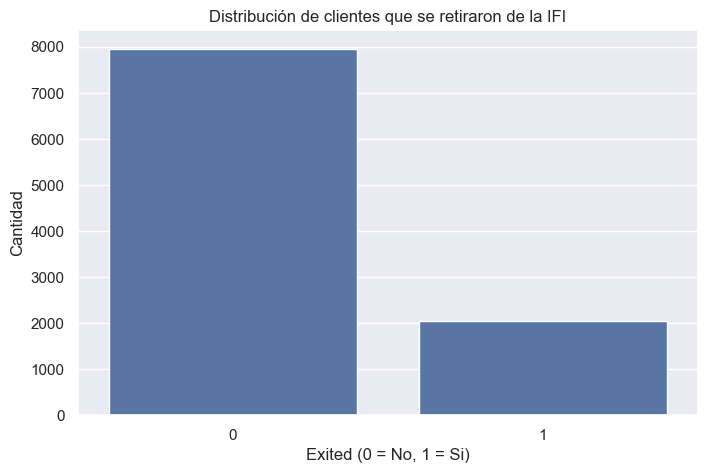

In [22]:
plt.figure(figsize = (8, 5))
sns.countplot(data = df, x = "Exited")
plt.title("Distribución de clientes que se retiraron de la IFI")
plt.xlabel("Exited (0 = No, 1 = Si)")
plt.ylabel("Cantidad")
plt.show()

### Visualización 2: Relación con la edad

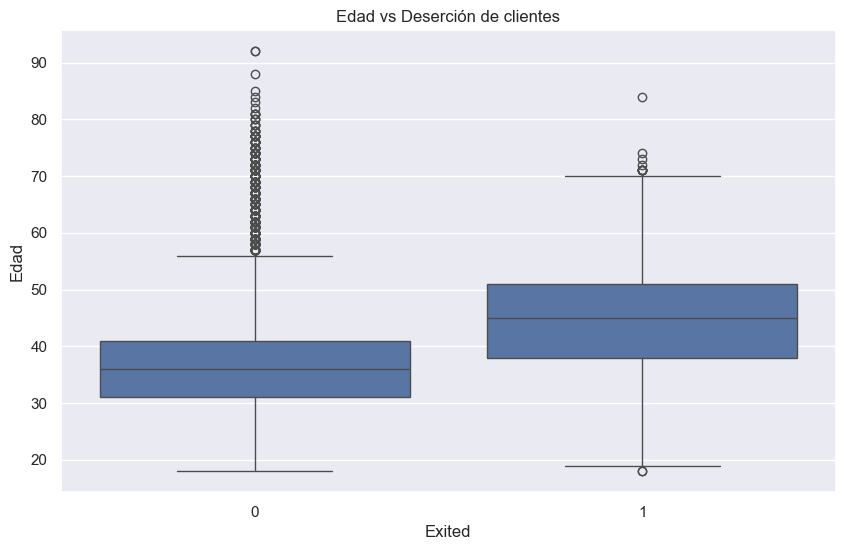

In [24]:
plt.figure(figsize = (10, 6))
sns.boxplot(data = df, x = "Exited", y = "Age")
plt.title("Edad vs Deserción de clientes")
plt.xlabel("Exited")
plt.ylabel("Edad")
plt.show()

### Visualización 3: Relación geográfica

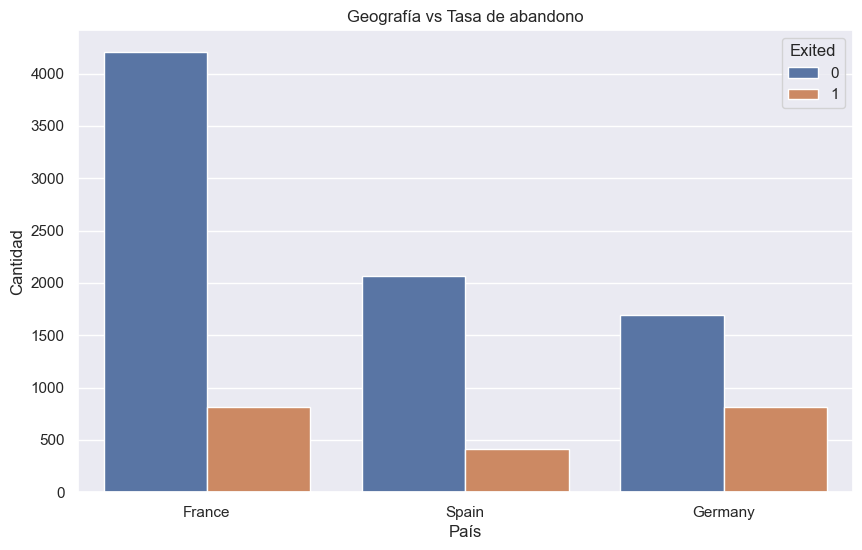

In [26]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x="Geography", hue="Exited")
plt.title("Geografía vs Tasa de abandono")
plt.xlabel("País")
plt.ylabel("Cantidad")
plt.show()

### Visualización 4: Balance vs Tasa de abandono

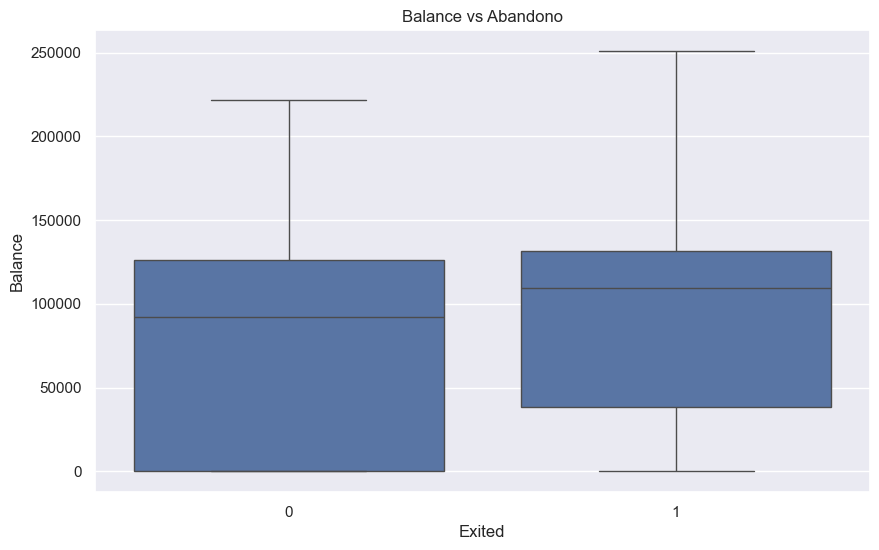

In [27]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="Exited", y="Balance")
plt.title("Balance vs Abandono")
plt.xlabel("Exited")
plt.ylabel("Balance")
plt.show()

### 5 Matriz de Correlación:

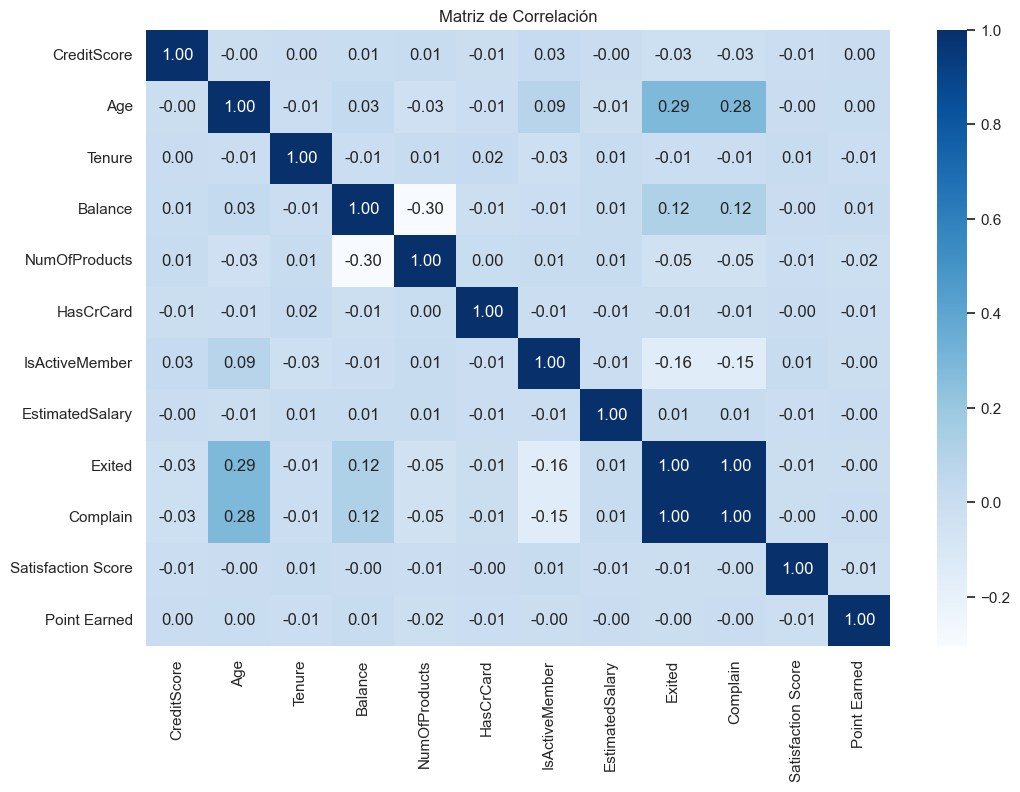

In [29]:
plt.figure(figsize=(12,8))
numericas = df.select_dtypes(include=np.number)
sns.heatmap(
    numericas.corr(),
    annot=True,
    fmt=".2f",
    cmap="Blues"
)
plt.title("Matriz de Correlación")
plt.show()

## 6 Análisis de deserción por segmentos:

In [13]:
# Crear una copia para análisis adicional
df_segmentos = df.copy()

# Función auxiliar para calcular tasa de churn
def tasa_churn_por_variable(data, variable):
    return (
        data.groupby(variable)["Exited"]
        .agg(Clientes="count", Clientes_Retirados="sum", Tasa_Churn="mean")
        .sort_values("Tasa_Churn", ascending=False)
        .reset_index()
    )

tasa_churn_por_variable(df_segmentos, "Geography")

,Geography,Clientes,Clientes_Retirados,Tasa_Churn
0,Germany,2509,814,0.324432
1,Spain,2477,413,0.166734
2,France,5014,811,0.161747


### Visualización 7: Tasa de deserción por país

In [16]:
import os
os.makedirs("screenshots", exist_ok=True)

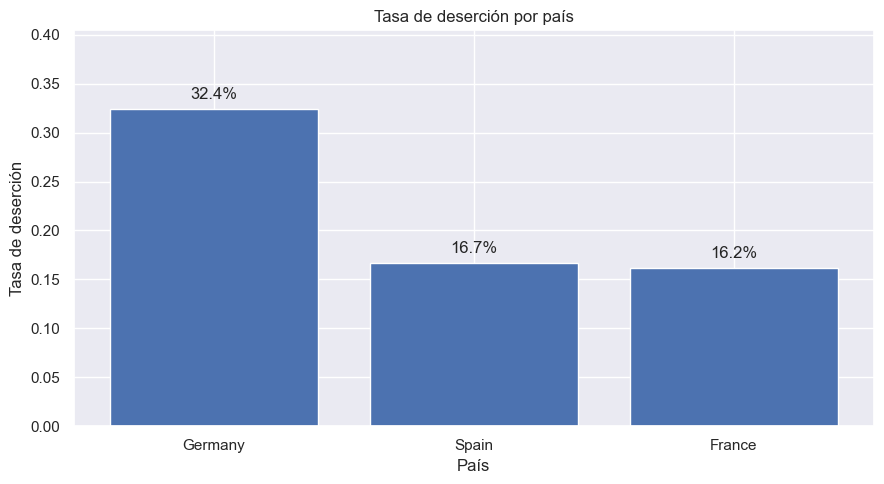

In [17]:
geo_churn = tasa_churn_por_variable(df_segmentos, "Geography")

plt.figure(figsize=(9,5))
plt.bar(geo_churn["Geography"].astype(str), geo_churn["Tasa_Churn"])

plt.title("Tasa de deserción por país")
plt.xlabel("País")
plt.ylabel("Tasa de deserción")
plt.ylim(0, geo_churn["Tasa_Churn"].max() + 0.08)

for i, value in enumerate(geo_churn["Tasa_Churn"]):
    plt.text(i, value + 0.01, f"{value:.1%}", ha="center")

plt.tight_layout()
plt.savefig("screenshots/aporte_tasa_churn_pais.png", dpi=150)
plt.show()

### Visualización 8: Deserción según actividad del cliente

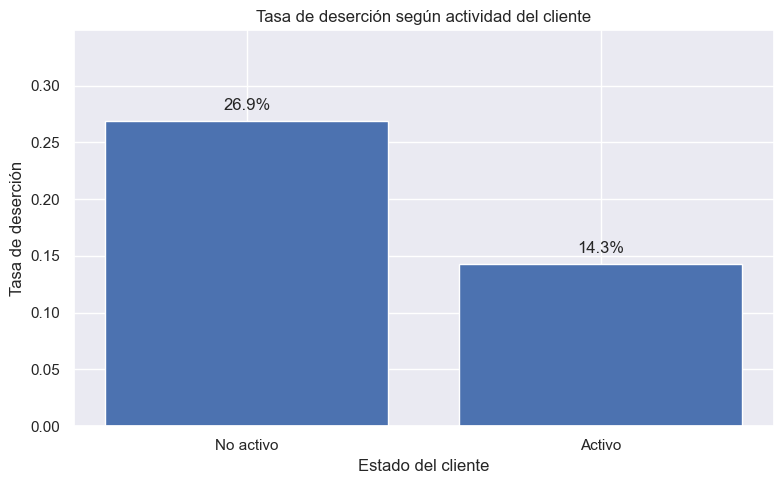

In [18]:
active_churn = tasa_churn_por_variable(df_segmentos, "IsActiveMember")
active_churn["Estado_Cliente"] = active_churn["IsActiveMember"].map({0: "No activo", 1: "Activo"})

plt.figure(figsize=(8,5))
plt.bar(active_churn["Estado_Cliente"], active_churn["Tasa_Churn"])

plt.title("Tasa de deserción según actividad del cliente")
plt.xlabel("Estado del cliente")
plt.ylabel("Tasa de deserción")
plt.ylim(0, active_churn["Tasa_Churn"].max() + 0.08)

for i, value in enumerate(active_churn["Tasa_Churn"]):
    plt.text(i, value + 0.01, f"{value:.1%}", ha="center")

plt.tight_layout()
plt.savefig("screenshots/aporte_churn_cliente_activo.png", dpi=150)
plt.show()

### Visualización 9: Deserción por número de productos

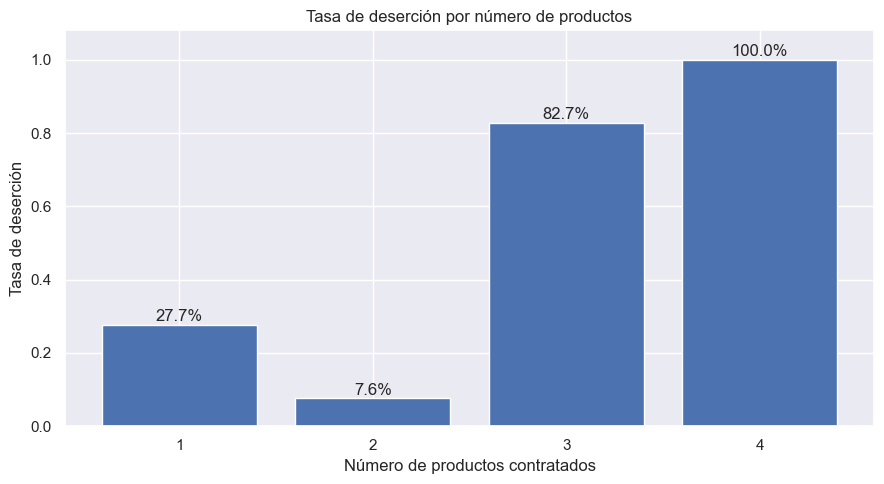

In [19]:
productos_churn = tasa_churn_por_variable(df_segmentos, "NumOfProducts").sort_values("NumOfProducts")

plt.figure(figsize=(9,5))
plt.bar(productos_churn["NumOfProducts"].astype(str), productos_churn["Tasa_Churn"])

plt.title("Tasa de deserción por número de productos")
plt.xlabel("Número de productos contratados")
plt.ylabel("Tasa de deserción")
plt.ylim(0, productos_churn["Tasa_Churn"].max() + 0.08)

for i, value in enumerate(productos_churn["Tasa_Churn"]):
    plt.text(i, value + 0.01, f"{value:.1%}", ha="center")

plt.tight_layout()
plt.savefig("screenshots/aporte_churn_num_productos.png", dpi=150)
plt.show()

### Visualización 10: Deserción por rango de edad

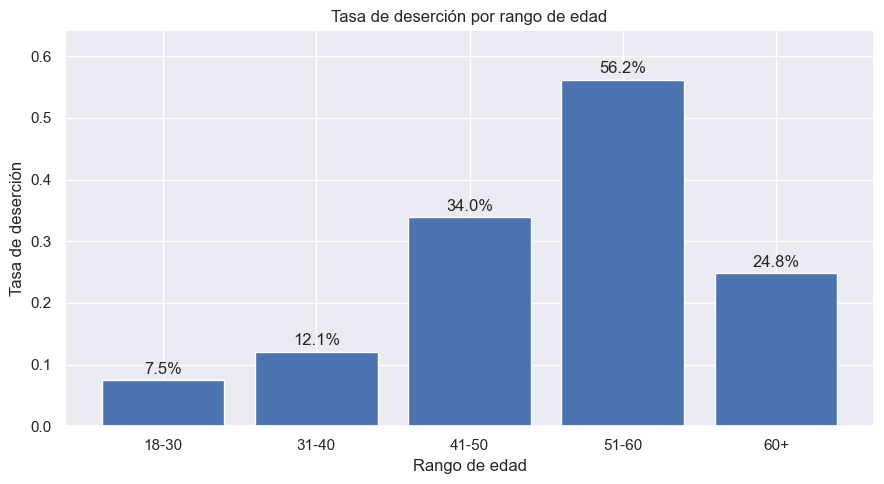

In [20]:
df_segmentos["Rango_Edad"] = pd.cut(
    df_segmentos["Age"],
    bins=[17, 30, 40, 50, 60, 100],
    labels=["18-30", "31-40", "41-50", "51-60", "60+"]
)

edad_churn = tasa_churn_por_variable(df_segmentos, "Rango_Edad").sort_values("Rango_Edad")

plt.figure(figsize=(9,5))
plt.bar(edad_churn["Rango_Edad"].astype(str), edad_churn["Tasa_Churn"])

plt.title("Tasa de deserción por rango de edad")
plt.xlabel("Rango de edad")
plt.ylabel("Tasa de deserción")
plt.ylim(0, edad_churn["Tasa_Churn"].max() + 0.08)

for i, value in enumerate(edad_churn["Tasa_Churn"]):
    plt.text(i, value + 0.01, f"{value:.1%}", ha="center")

plt.tight_layout()
plt.savefig("screenshots/aporte_churn_rango_edad.png", dpi=150)
plt.show()